In [1]:
import pandas as pd

# engine 可以用 pyarrow 或 fastparquet，兩個都行
df = pd.read_parquet('/content/health_dataset.parquet', engine='pyarrow')
df.head()

,Edu_level,Gen_health_state,Life_satisfaction,Mental_health_state,Stress_level,Work_stress,Sense_belonging,Fruit_veg_con,Total_active_time,Total_physical_act_time,...,Birth_country_9,Immigrant_2,Immigrant_9,Insurance_cover_2,Insurance_cover_6,Insurance_cover_7,Insurance_cover_8,Insurance_cover_9,Income_source_2,Income_source_9
0,-0.000906,0.563802,9.0,0.881354,-0.565478,-0.939196,-0.127853,-1.745466,-2.086782,-2.082262,...,False,True,False,False,False,False,False,False,False,False
1,-0.646272,0.563802,4.0,0.881354,0.417423,0.755871,1.097969,-1.745536,-2.086782,-2.082262,...,False,True,False,False,False,False,False,False,True,False
2,-1.291639,-0.394318,7.0,0.881354,0.417423,-0.939196,-0.127853,0.573395,0.484533,0.485451,...,False,True,False,False,True,False,False,False,True,False
3,-1.291639,0.563802,8.0,0.881354,0.417423,0.008524,-0.127853,0.573395,0.484533,0.485451,...,False,True,False,False,True,False,False,False,True,False
4,-0.000906,2.480043,0.0,2.943629,1.400324,1.633357,1.097969,0.573395,0.484533,0.485451,...,False,True,False,True,False,False,False,False,True,False


In [2]:
# 準備特徵與目標欄位
X = df.drop(columns=['Stress_level'])
y = df['Stress_level']

In [3]:
import numpy as np
import pandas as pd

selected_features = [
    'Age_5', 'Immigrant_2', 'Drug_use_9', 'Marital_status_2', 'Tobaco_use_9',
    'Age_4', 'Marital_status_9', 'Drug_use_2', 'Birth_country_2', 'Age_3',
    'Weight_state_2', 'Work_hours _35.0', 'Tobaco_use_2', 'Work_hours _40.0',
    'working_status _9', 'BMI_2.0', 'Gen_health_state', 'Insurance_cover_2',
    'Household_2', 'High_cholestrol_8'
]


In [4]:
# 找出 selected_features 中哪些欄位真的在 df 中
available_features = [col for col in selected_features if col in df.columns]
missing_features = [col for col in selected_features if col not in df.columns]

# 印出結果讓你確認
print(f"✅ 找到 {len(available_features)} 個欄位：\n", available_features)
if missing_features:
    print(f"❌ 找不到這些欄位（可能有空格錯字）：\n", missing_features)

# 建立 X_selected（自動處理缺值）
X_selected = df[available_features].fillna(0)


✅ 找到 20 個欄位：
 ['Age_5', 'Immigrant_2', 'Drug_use_9', 'Marital_status_2', 'Tobaco_use_9', 'Age_4', 'Marital_status_9', 'Drug_use_2', 'Birth_country_2', 'Age_3', 'Weight_state_2', 'Work_hours _35.0', 'Tobaco_use_2', 'Work_hours _40.0', 'working_status _9', 'BMI_2.0', 'Gen_health_state', 'Insurance_cover_2', 'Household_2', 'High_cholestrol_8']


In [5]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.kernel_ridge import KernelRidge
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
}

for name, model in models.items():
    pipeline = make_pipeline(StandardScaler(), model)
    score = cross_val_score(pipeline, X_selected, y, cv=5, scoring='r2')
    print(f"{name} R²: {score.mean():.4f}")


Linear Regression R²: 0.1491
Ridge Regression R²: 0.1491
Lasso Regression R²: -0.0000


In [6]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor

tree_models = {
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "HistGradient Boosting": HistGradientBoostingRegressor(random_state=42)
}

for name, model in tree_models.items():
    pipeline = make_pipeline(StandardScaler(), model)
    score = cross_val_score(pipeline, X_selected, y, cv=5, scoring='r2')
    print(f"{name} R²: {score.mean():.4f}")



Random Forest R²: 0.1179
Gradient Boosting R²: 0.1598
HistGradient Boosting R²: 0.1619


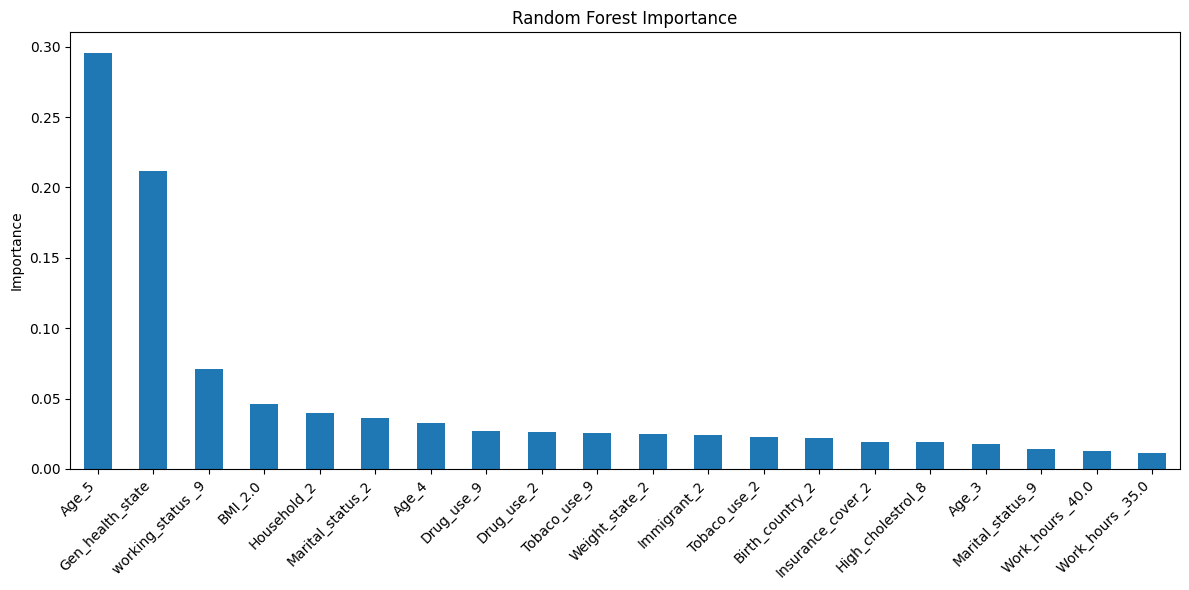

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# 重新訓練模型（如果你之前沒有保存 model）
pipeline = make_pipeline(StandardScaler(), RandomForestRegressor(random_state=42))
pipeline.fit(X_selected, y)

# 取出模型中的 RandomForest 對象
rf_model = pipeline.named_steps['randomforestregressor']

# 建立特徵重要性 DataFrame
feature_importance = pd.Series(rf_model.feature_importances_, index=X_selected.columns)
feature_importance_sorted = feature_importance.sort_values(ascending=False)

# 畫圖
plt.figure(figsize=(12, 6))
feature_importance_sorted.plot(kind='bar')
plt.title("Random Forest Importance")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [9]:
from sklearn.svm import LinearSVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

# 設定模型
linear_svr_pipeline = make_pipeline(
    StandardScaler(),
    LinearSVR(max_iter=5000, random_state=42)  # 增加迭代次數保險一點
)

# 做交叉驗證
scores = cross_val_score(linear_svr_pipeline, X_selected, y, cv=5, scoring='r2')

# 顯示結果
print(f"LinearSVR R²: {scores.mean():.4f} ± {scores.std():.4f}")


LinearSVR R²: 0.0299 ± 0.0063


In [8]:
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

mlp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(hidden_layer_sizes=(16,), activation='relu',
                         learning_rate_init=0.001, max_iter=300, random_state=42))
])

scores = cross_val_score(mlp_pipeline, X_selected, y, cv=3, scoring='r2')
print(f"R²: {scores.mean():.4f} ± {scores.std():.4f}")



R²: 0.1575 ± 0.0021


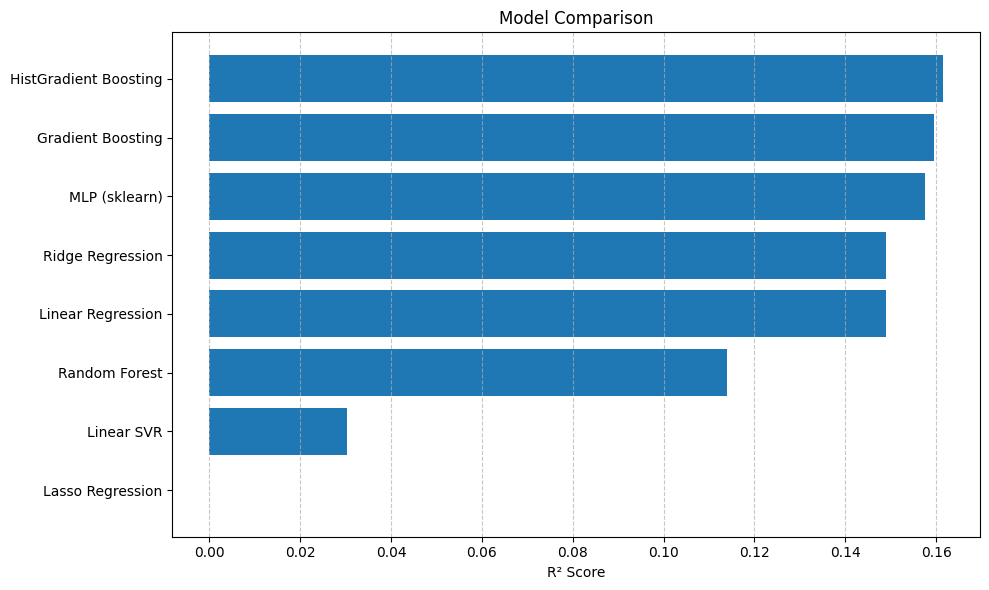

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.svm import LinearSVR
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam


# 所有模型
final_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "HistGradient Boosting": HistGradientBoostingRegressor(random_state=42),
    "Linear SVR": LinearSVR(random_state=42, max_iter=1000),
    "MLP (sklearn)": MLPRegressor(hidden_layer_sizes=(16,), activation='relu',
                                   learning_rate_init=0.001, max_iter=300, random_state=42)
}
# 計算 R² 分數
r2_scores = {}
for name, model in final_models.items():
    pipeline = make_pipeline(StandardScaler(), model)
    score = cross_val_score(pipeline, X_selected, y, cv=3, scoring='r2')  # 用 cv=3 保守估計
    r2_scores[name] = score.mean()

# 整理成 DataFrame
r2_df = pd.DataFrame(list(r2_scores.items()), columns=['Model', 'R²']).sort_values(by='R²', ascending=False)

# 畫圖
plt.figure(figsize=(10, 6))
plt.barh(r2_df['Model'], r2_df['R²'])
plt.xlabel("R² Score")
plt.title("Model Comparison")
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
